In [ ]:
# ============================================================
# CELL 1: All imports and global configuration
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             matthews_corrcoef, roc_auc_score, roc_curve, auc, confusion_matrix)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Global reproducibility seed
RANDOM_STATE = 42

# Cross-validation scheme used throughout the study (as stated in the paper)
CV_SCHEME = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Environment ready.")

Environment ready.


In [ ]:
# ============================================================
# CELL 2: Load dataset, remove duplicates, impute missing
# values, and apply categorical encoding
# ============================================================
# 1. Load the dataset
df = pd.read_csv('/content/Depression Dataset (2).csv')
print("Raw dataset shape:", df.shape)

# 2. Remove absolute duplicate records (leakage prevention, Section 2.2)
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after duplicate removal:", df.shape)

# 3. Mode imputation for missing values (Section 2.2)
imputer = SimpleImputer(strategy='most_frequent')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# 4. Feature categories (Table 1 codebook)
target = 'DEPRESSED'

yes_no_cols = ['ENVSAT', 'POSSAT', 'FINSTR', 'DEBT', 'SMOKE', 'DRINK',
               'ILLNESS', 'PREMED', 'EATDIS', 'INSOM', 'ANXI', 'DEPRI',
               'ABUSED', 'CHEAT', 'THREAT', 'SUICIDE', 'INFER', 'CONFLICT', 'LOST']
custom_binary_col = 'LIVWTH'
ordinal_cols = ['AGERNG', 'EDU', 'PHYEX', 'AVGSLP', 'TSSN', 'WRKPRE']
nominal_cols = ['GENDER', 'PROF', 'MARSTS', 'RESDPL']

# 5. Binary mapping for Yes/No features (Section 2.3)
for col in yes_no_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Binary mapping for the living-arrangement feature
df[custom_binary_col] = df[custom_binary_col].map({'With Family': 1, 'Without Family': 0})

# Target is already 0/1; enforce integer type
df[target] = df[target].astype(int)

# 6. Ordinal encoding with explicit hierarchical order (Section 2.3)
ordinal_categories = [
    ['16-20', '21-25', '26-30', '31-35', '36-40', '41-45', '46-50', '51-55', '56-60', '61+'],  # AGERNG
    ['SSC', 'HSC', 'Graduate', 'Post Graduate'],                                               # EDU
    ['Never', 'Sometimes', 'Regularly'],                                                       # PHYEX
    ['Below 5 hours', '5 hours', '6 hours', '7 hours', '8 hours', 'More than 8 hours'],        # AVGSLP
    ['Less than 2 hours', '2-4 hours a day', '5-7 hours a day',
     '8-10 hours a day', 'More than 10 hours a day'],                                          # TSSN
    ['No Pressure', 'Mild', 'Moderate', 'Severe']                                              # WRKPRE
]
ordinal_encoder = OrdinalEncoder(categories=ordinal_categories)
df[ordinal_cols] = ordinal_encoder.fit_transform(df[ordinal_cols])

# 7. One-hot encoding for nominal features (Section 2.3)
df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# 8. Feature matrix and target vector
X = df_encoded.drop(columns=[target]).astype(float)
y = df_encoded[target].astype(int)
feature_names = X.columns.tolist()

# 9. Class distribution report (for Section 2.1 of the paper)
print("\nFinal feature matrix shape:", X.shape)
print("Class distribution:\n", y.value_counts())
print("Class ratio: {:.2f}% depressed".format(y.mean() * 100))

Raw dataset shape: (739, 31)
Shape after duplicate removal: (729, 31)

Final feature matrix shape: (729, 36)
Class distribution:
 DEPRESSED
1    502
0    227
Name: count, dtype: int64
Class ratio: 68.86% depressed


In [ ]:
# ============================================================
# CELL 3: Stratified 80/20 split, scaling, and SMOTE
# (holdout pipeline used for Table 3 test columns and figures)
# ============================================================
# 1. Stratified train-test partitioning (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

# 2. Feature scaling: fit ONLY on training data, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. SMOTE applied ONLY to the scaled training partition
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("Training shape after SMOTE:", X_train_bal.shape)
print("Balanced class counts:", np.bincount(y_train_bal))
print("Test shape (untouched):", X_test_scaled.shape)

Training shape after SMOTE: (802, 36)
Balanced class counts: [401 401]
Test shape (untouched): (146, 36)


In [ ]:
# ============================================================
# CELL 4: GridSearchCV with Scaler+SMOTE INSIDE each CV fold
# (fully leakage-free tuning; will become a new subsection
# in the paper's methodology)
# ============================================================
# 1. Models and their hyperparameter search spaces
model_grids = {
    'Logistic Regression': (
        LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
        {'model__C': [0.1, 1, 10]}),
    'SVM': (
        SVC(probability=True, random_state=RANDOM_STATE),
        {'model__C': [0.1, 1, 10], 'model__kernel': ['rbf', 'linear']}),
    'KNN': (
        KNeighborsClassifier(),
        {'model__n_neighbors': [3, 5, 7], 'model__weights': ['uniform', 'distance']}),
    'Naive Bayes': (
        GaussianNB(),
        {'model__var_smoothing': [1e-9, 1e-8, 1e-7]}),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {'model__max_depth': [None, 10, 20], 'model__min_samples_split': [2, 5, 10]}),
    'Random Forest': (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {'model__n_estimators': [100, 200], 'model__max_depth': [None, 10, 20]}),
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {'model__n_estimators': [100, 200], 'model__learning_rate': [0.01, 0.1, 0.2]}),
    'AdaBoost': (
        AdaBoostClassifier(random_state=RANDOM_STATE),
        {'model__n_estimators': [50, 100], 'model__learning_rate': [0.1, 1.0]}),
    'XGBoost': (
        XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
        {'model__n_estimators': [100, 200], 'model__learning_rate': [0.01, 0.1, 0.2],
         'model__max_depth': [3, 6]})
}

best_pipelines = {}   # stores the best fitted pipeline per model
best_params = {}      # stores the best hyperparameters per model
best_cv_scores = {}

# 2. Tune each model with the leakage-free pipeline
for name, (model, grid) in model_grids.items():
    pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', model)
    ])
    gs = GridSearchCV(pipeline, grid, cv=CV_SCHEME, scoring='accuracy', n_jobs=-1)
    gs.fit(X_train, y_train)   # raw training data; scaling/SMOTE happen inside folds
    best_pipelines[name] = gs.best_estimator_
    best_params[name] = gs.best_params_
    best_cv_scores[name] = gs.best_score_
    print(f"{name}: best params = {gs.best_params_}")

print("\nHyperparameter tuning completed for all 9 models.")

Logistic Regression: best params = {'model__C': 1}
SVM: best params = {'model__C': 0.1, 'model__kernel': 'linear'}
KNN: best params = {'model__n_neighbors': 3, 'model__weights': 'uniform'}
Naive Bayes: best params = {'model__var_smoothing': 1e-09}
Decision Tree: best params = {'model__max_depth': 10, 'model__min_samples_split': 10}
Random Forest: best params = {'model__max_depth': None, 'model__n_estimators': 100}
Gradient Boosting: best params = {'model__learning_rate': 0.1, 'model__n_estimators': 100}
AdaBoost: best params = {'model__learning_rate': 1.0, 'model__n_estimators': 50}
XGBoost: best params = {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 200}

Hyperparameter tuning completed for all 9 models.


In [ ]:
# ============================================================
# CELL 5: Compute Table 3 exactly as structured in the paper:
# CV ROC-AUC (Stratified 5-Fold on training data) +
# all holdout test metrics
# ============================================================
results = []

for name, pipeline in best_pipelines.items():
    # 1. CV ROC-AUC: 5-fold cross-validation on the training partition
    cv_auc = cross_val_score(pipeline, X_train, y_train,
                             cv=CV_SCHEME, scoring='roc_auc', n_jobs=-1).mean()

    # 2. Holdout test predictions (pipeline handles scaling internally;
    #    SMOTE is automatically bypassed at prediction time)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # 3. All Table 3 metrics
    results.append([
        name,
        round(cv_auc, 4),
        round(roc_auc_score(y_test, y_prob), 4),
        round(accuracy_score(y_test, y_pred) * 100, 2),
        round(precision_score(y_test, y_pred) * 100, 2),
        round(recall_score(y_test, y_pred) * 100, 2),
        round(f1_score(y_test, y_pred) * 100, 2),
        round(matthews_corrcoef(y_test, y_pred), 4)
    ])

table3 = pd.DataFrame(results, columns=[
    'Classifier', 'CV ROC-AUC', 'Test ROC-AUC', 'Accuracy (%)',
    'Precision (%)', 'Recall (%)', 'F1-Score (%)', 'MCC'])

table3_sorted = table3.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
print("--- Table 3: Comparative Predictive Performance Matrix ---\n")
print(table3_sorted.to_string(index=False))

champion_name = max(best_cv_scores, key=best_cv_scores.get)
print(f"\nChampion model (selected by CV accuracy, test set untouched): {champion_name} "
      f"(CV Accuracy = {best_cv_scores[champion_name]*100:.2f}%)")

table3 = table3_sorted

--- Table 3: Comparative Predictive Performance Matrix ---

         Classifier  CV ROC-AUC  Test ROC-AUC  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)    MCC
Logistic Regression      0.9007        0.8983         84.93          92.47       85.15         88.66 0.6683
  Gradient Boosting      0.8946        0.8900         84.25          88.24       89.11         88.67 0.6284
      Random Forest      0.9041        0.8754         82.19          86.41       88.12         87.25 0.5775
                SVM      0.9034        0.9001         80.82          91.95       79.21         85.11 0.5990
           AdaBoost      0.8968        0.8804         80.82          87.63       84.16         85.86 0.5622
            XGBoost      0.8955        0.8758         80.14          86.73       84.16         85.43 0.5433
        Naive Bayes      0.8689        0.8540         78.77          88.89       79.21         83.77 0.5411
      Decision Tree      0.7899        0.7392         73.29          81.00  

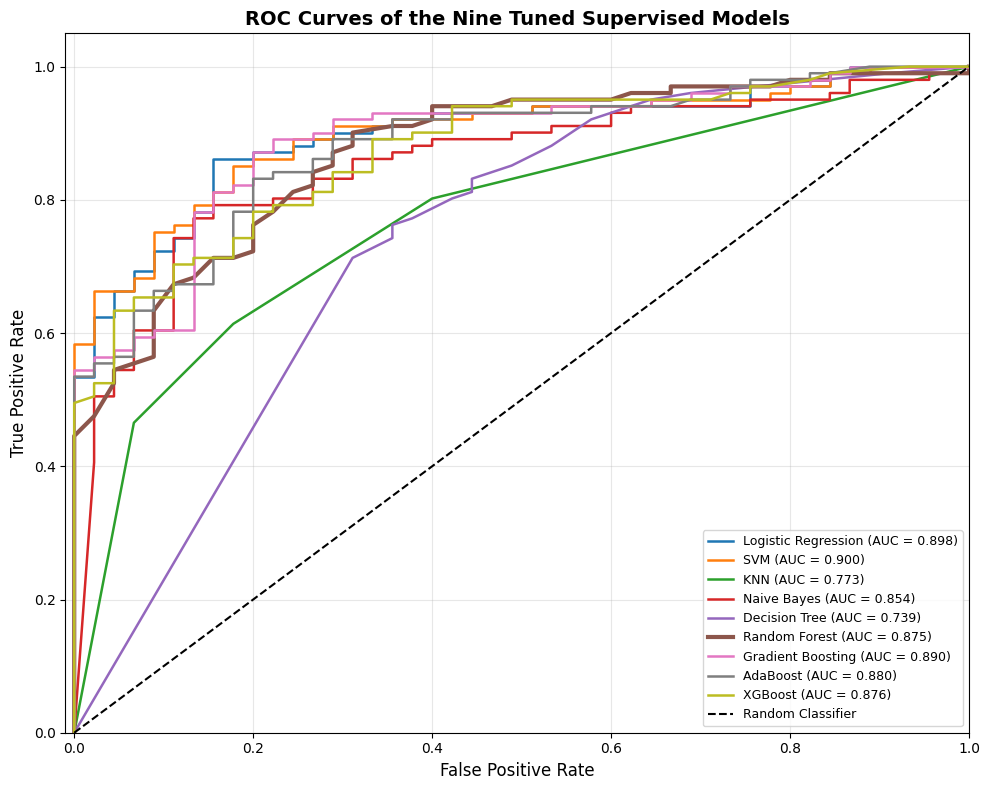

Saved: Figure1_ROC_Curves.png


In [ ]:
# ============================================================
# CELL 6: Figure 1 - ROC curves of all 9 tuned models
# (saved at 300 DPI for journal submission)
# ============================================================
plt.figure(figsize=(10, 8))

for name, pipeline in best_pipelines.items():
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    lw = 3.0 if name == champion_name else 1.8
    plt.plot(fpr, tpr, lw=lw, label=f'{name} (AUC = {roc_auc_val:.3f})')

plt.plot([0, 1], [0, 1], color='black', lw=1.5, linestyle='--', label='Random Classifier')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves of the Nine Tuned Supervised Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Figure1_ROC_Curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: Figure1_ROC_Curves.png")

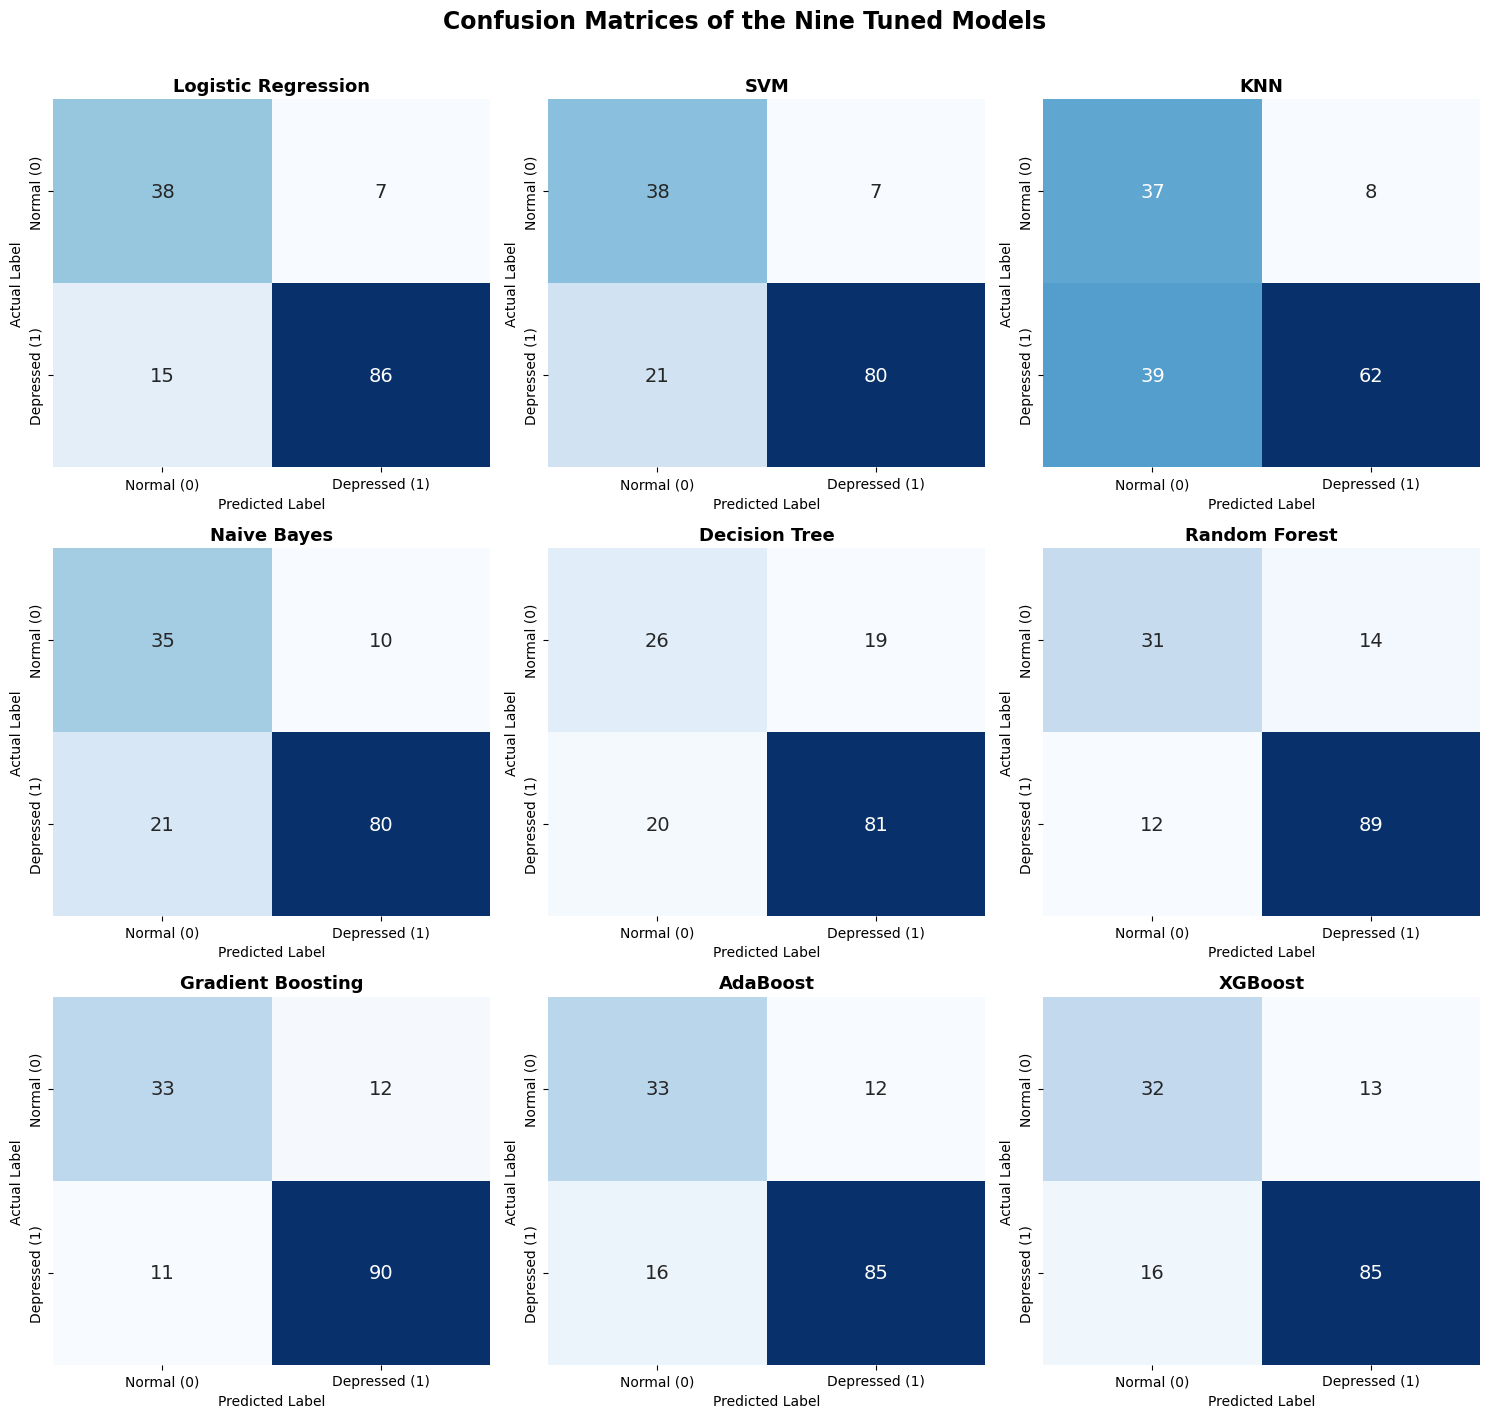

Saved: Figure2_Confusion_Matrices.png
[[32 13]
 [16 85]]


In [ ]:
# ============================================================
# CELL 7: Figure 2 - Confusion matrices for all 9 models
# ============================================================
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 14))
axes = axes.ravel()

for idx, (name, pipeline) in enumerate(best_pipelines.items()):
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                ax=axes[idx], annot_kws={"size": 14})
    axes[idx].set_title(name, fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=10)
    axes[idx].set_ylabel('Actual Label', fontsize=10)
    axes[idx].set_xticklabels(['Normal (0)', 'Depressed (1)'])
    axes[idx].set_yticklabels(['Normal (0)', 'Depressed (1)'])

fig.suptitle('Confusion Matrices of the Nine Tuned Models', fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('Figure2_Confusion_Matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: Figure2_Confusion_Matrices.png")
print(confusion_matrix(y_test, y_pred))

In [ ]:
# ============================================================
# CELL 8: Generalization check - |Test AUC - CV AUC| <= 0.05
# (real computation backing Section 3.4 of the paper)
# ============================================================
print(f"{'Classifier':<22}{'CV AUC':>10}{'Test AUC':>10}{'Delta':>10}  Status")
print("-" * 62)

for _, row in table3.iterrows():
    delta = abs(row['Test ROC-AUC'] - row['CV ROC-AUC'])
    status = "OK (no significant overfitting)" if delta <= 0.05 else "CHECK"
    print(f"{row['Classifier']:<22}{row['CV ROC-AUC']:>10.4f}"
          f"{row['Test ROC-AUC']:>10.4f}{delta:>10.4f}  {status}")

Classifier                CV AUC  Test AUC     Delta  Status
--------------------------------------------------------------
Logistic Regression       0.9007    0.8983    0.0024  OK (no significant overfitting)
Gradient Boosting         0.8946    0.8900    0.0046  OK (no significant overfitting)
Random Forest             0.9041    0.8754    0.0287  OK (no significant overfitting)
SVM                       0.9034    0.9001    0.0033  OK (no significant overfitting)
AdaBoost                  0.8968    0.8804    0.0164  OK (no significant overfitting)
XGBoost                   0.8955    0.8758    0.0197  OK (no significant overfitting)
Naive Bayes               0.8689    0.8540    0.0149  OK (no significant overfitting)
Decision Tree             0.7899    0.7392    0.0507  CHECK
KNN                       0.8017    0.7734    0.0283  OK (no significant overfitting)


In [ ]:
# ============================================================
# CELL 9: Persist the champion pipeline and metadata
# (needed later for SHAP/LIME and the Streamlit web app)
# ============================================================
champion_pipeline = best_pipelines[champion_name]

joblib.dump(champion_pipeline, 'champion_model.pkl')
joblib.dump(feature_names, 'feature_names.pkl')
joblib.dump(ordinal_encoder, 'ordinal_encoder.pkl')

print(f"Saved champion pipeline: {champion_name} -> champion_model.pkl")
print("Saved feature names -> feature_names.pkl")
print("Saved ordinal encoder -> ordinal_encoder.pkl")

Saved champion pipeline: Random Forest -> champion_model.pkl
Saved feature names -> feature_names.pkl
Saved ordinal encoder -> ordinal_encoder.pkl


In [ ]:
# ============================================================
# CELL 10: Install explainability libraries
# ============================================================
!pip install shap lime -q
import shap
import lime
from lime.lime_tabular import LimeTabularExplainer
print("SHAP version:", shap.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
SHAP version: 0.52.0


  0%|          | 0/146 [00:00<?, ?it/s]

SHAP values computed. Shape: (146, 36)


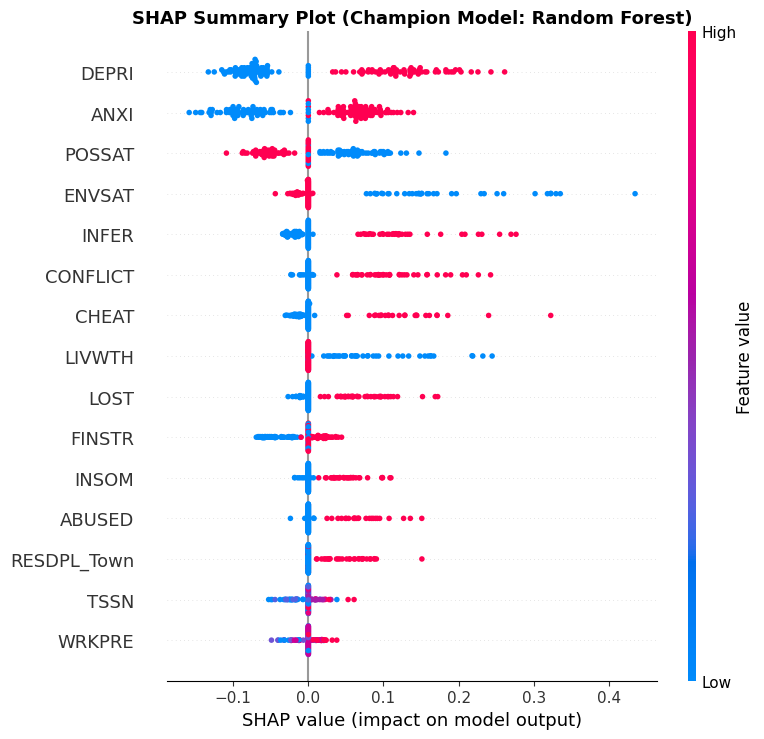

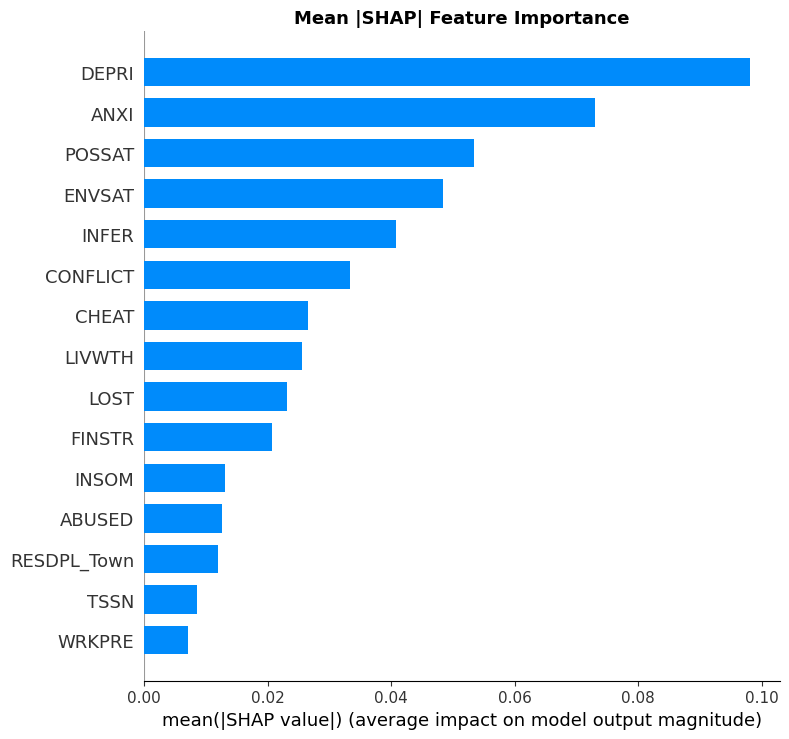


--- Top 15 Features by Mean |SHAP| ---
    Feature  Mean |SHAP|
      DEPRI     0.098048
       ANXI     0.072953
     POSSAT     0.053420
     ENVSAT     0.048448
      INFER     0.040718
   CONFLICT     0.033311
      CHEAT     0.026616
     LIVWTH     0.025649
       LOST     0.023183
     FINSTR     0.020795
      INSOM     0.013169
     ABUSED     0.012634
RESDPL_Town     0.011982
       TSSN     0.008582
     WRKPRE     0.007164


In [ ]:
# ============================================================
# CELL 11: SHAP analysis of the champion AdaBoost pipeline
# (KernelExplainer on raw feature space; takes 5-10 minutes)
# ============================================================
# 1. Prediction function: probability of the 'Depressed' class,
#    routed through the full pipeline (scaling handled inside)
predict_depressed = lambda arr: champion_pipeline.predict_proba(
    pd.DataFrame(arr, columns=feature_names))[:, 1]

# 2. Background distribution summarized with k-means (speeds up SHAP)
background = shap.kmeans(X_train.values, 25)

# 3. Build the explainer and compute SHAP values for the test set
explainer = shap.KernelExplainer(predict_depressed, background)
shap_values = explainer.shap_values(X_test.values, nsamples=200)
print("SHAP values computed. Shape:", np.array(shap_values).shape)

# 4. Figure 3: SHAP summary (beeswarm) plot - global direction of impact
shap.summary_plot(shap_values, X_test, feature_names=feature_names,
                  max_display=15, show=False)
plt.title(f'SHAP Summary Plot (Champion Model: {champion_name})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure3_SHAP_Summary.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Figure 4: SHAP bar plot - mean absolute impact per feature
shap.summary_plot(shap_values, X_test, feature_names=feature_names,
                  plot_type='bar', max_display=15, show=False)
plt.title('Mean |SHAP| Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure4_SHAP_Importance.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. Top-15 feature table for the paper's results text
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_rank = pd.DataFrame({'Feature': feature_names, 'Mean |SHAP|': mean_abs_shap})
shap_rank = shap_rank.sort_values('Mean |SHAP|', ascending=False).head(15)
print("\n--- Top 15 Features by Mean |SHAP| ---")
print(shap_rank.to_string(index=False))

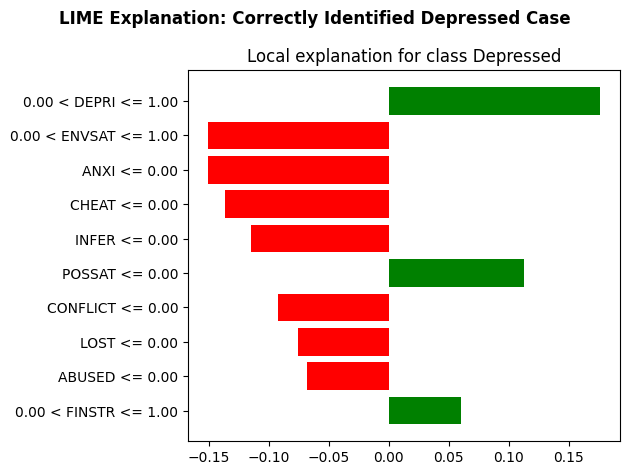

Depressed case - predicted probability: 0.53


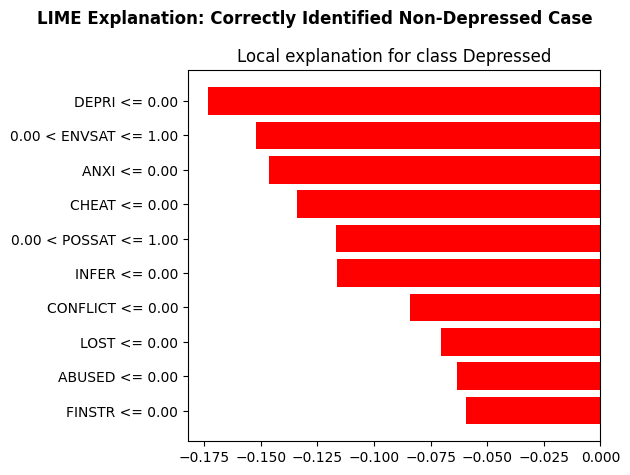

Non-depressed case - predicted probability of depression: 0.15


In [ ]:
# ============================================================
# CELL 12: LIME local explanations for two individual cases
# (one correctly identified depressed, one correctly identified
# non-depressed) - gives the paper its clinical storytelling
# ============================================================
# 1. Build the LIME explainer on raw training data
lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=['Not Depressed', 'Depressed'],
    mode='classification',
    discretize_continuous=True,
    random_state=RANDOM_STATE)

# 2. Pipeline-based prediction function (both class probabilities)
predict_fn = lambda arr: champion_pipeline.predict_proba(
    pd.DataFrame(arr, columns=feature_names))

# 3. Locate one true positive and one true negative in the test set
y_pred_champ = champion_pipeline.predict(X_test)
y_test_arr = y_test.to_numpy()

tp_idx = np.where((y_test_arr == 1) & (y_pred_champ == 1))[0][0]  # depressed, caught
tn_idx = np.where((y_test_arr == 0) & (y_pred_champ == 0))[0][0]  # healthy, cleared

# 4. Figure 5: explanation for the depressed individual
exp_tp = lime_explainer.explain_instance(
    X_test.values[tp_idx], predict_fn, num_features=10)
fig = exp_tp.as_pyplot_figure()
fig.suptitle('LIME Explanation: Correctly Identified Depressed Case', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure5_LIME_Depressed.png', dpi=300, bbox_inches='tight')
plt.show()
print("Depressed case - predicted probability:",
      round(predict_fn(X_test.values[tp_idx:tp_idx+1])[0][1], 3))

# 5. Figure 6: explanation for the non-depressed individual
exp_tn = lime_explainer.explain_instance(
    X_test.values[tn_idx], predict_fn, num_features=10)
fig = exp_tn.as_pyplot_figure()
fig.suptitle('LIME Explanation: Correctly Identified Non-Depressed Case', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure6_LIME_NonDepressed.png', dpi=300, bbox_inches='tight')
plt.show()
print("Non-depressed case - predicted probability of depression:",
      round(predict_fn(X_test.values[tn_idx:tn_idx+1])[0][1], 3))

In [ ]:
# ============================================================
# CELL 13: FINAL ACCURACY PUSH (leakage-free)
# Expanded grids + SMOTE variants + LightGBM/CatBoost/ExtraTrees.
# RULE: champion is selected by CV score ONLY; the test set is
# evaluated once at the end for reporting.
# ============================================================
!pip install lightgbm catboost -q
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.combine import SMOTETomek

# 1. Expanded search spaces (edge values from Round-1 now interior points)
push_grids = {
    'AdaBoost': (AdaBoostClassifier(random_state=RANDOM_STATE), {
        'model__n_estimators': [100, 200, 300, 500],
        'model__learning_rate': [0.3, 0.5, 1.0, 1.5]}),
    'Logistic Regression': (LogisticRegression(random_state=RANDOM_STATE, max_iter=2000), {
        'model__C': [0.01, 0.05, 0.1, 0.3]}),
    'SVM': (SVC(probability=True, random_state=RANDOM_STATE), {
        'model__C': [0.01, 0.05, 0.1, 0.5],
        'model__kernel': ['linear', 'rbf']}),
    'Gradient Boosting': (GradientBoostingClassifier(random_state=RANDOM_STATE), {
        'model__n_estimators': [200, 400, 600],
        'model__learning_rate': [0.005, 0.01, 0.05],
        'model__max_depth': [2, 3]}),
    'XGBoost': (XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'), {
        'model__n_estimators': [200, 400, 600],
        'model__learning_rate': [0.005, 0.01, 0.05],
        'model__max_depth': [2, 3, 4]}),
    'LightGBM': (LGBMClassifier(random_state=RANDOM_STATE, verbose=-1), {
        'model__n_estimators': [200, 400],
        'model__learning_rate': [0.01, 0.05],
        'model__max_depth': [3, 5, -1]}),
    'CatBoost': (CatBoostClassifier(random_state=RANDOM_STATE, verbose=0), {
        'model__iterations': [200, 400],
        'model__learning_rate': [0.01, 0.05],
        'model__depth': [3, 5]}),
    'Extra Trees': (ExtraTreesClassifier(random_state=RANDOM_STATE), {
        'model__n_estimators': [200, 400],
        'model__max_depth': [None, 10, 20]})
}

# 2. Resampler variants tested INSIDE the pipeline via the grid
resamplers = [SMOTE(random_state=RANDOM_STATE),
              BorderlineSMOTE(random_state=RANDOM_STATE),
              SMOTETomek(random_state=RANDOM_STATE)]

push_results = []
push_pipelines = {}

for name, (model, grid) in push_grids.items():
    pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', model)])
    full_grid = dict(grid)
    full_grid['smote'] = resamplers   # resampler choice is tuned too
    gs = GridSearchCV(pipeline, full_grid, cv=CV_SCHEME,
                      scoring='accuracy', n_jobs=-1)
    gs.fit(X_train, y_train)
    push_pipelines[name] = gs.best_estimator_
    push_results.append([name, round(gs.best_score_ * 100, 2), gs.best_params_])
    print(f"{name}: CV accuracy = {gs.best_score_*100:.2f}%")

# 3. Rank by CV score and declare the champion BEFORE touching the test set
push_df = pd.DataFrame(push_results, columns=['Model', 'CV Accuracy (%)', 'Best Params'])
push_df = push_df.sort_values('CV Accuracy (%)', ascending=False).reset_index(drop=True)
print("\n--- CV Ranking (champion selected from this column) ---")
print(push_df[['Model', 'CV Accuracy (%)']].to_string(index=False))
print("\nBest params of CV champion:\n", push_df.iloc[0]['Best Params'])

# 4. ONE final holdout evaluation of every tuned pipeline (for Table 3)
final_rows = []
for name, pipe in push_pipelines.items():
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    final_rows.append([name,
        round(accuracy_score(y_test, y_pred) * 100, 2),
        round(precision_score(y_test, y_pred) * 100, 2),
        round(recall_score(y_test, y_pred) * 100, 2),
        round(f1_score(y_test, y_pred) * 100, 2),
        round(matthews_corrcoef(y_test, y_pred), 4),
        round(roc_auc_score(y_test, y_prob), 4)])
final_df = pd.DataFrame(final_rows, columns=['Model', 'Accuracy (%)', 'Precision (%)',
    'Recall (%)', 'F1 (%)', 'MCC', 'Test ROC-AUC']).sort_values('Accuracy (%)', ascending=False)
print("\n--- Holdout Test Results (reported once) ---")
print(final_df.to_string(index=False))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 3.5 MB/s eta 0:00:00
AdaBoost: CV accuracy = 84.91%
Logistic Regression: CV accuracy = 83.03%
SVM: CV accuracy = 83.54%
Gradient Boosting: CV accuracy = 83.88%
XGBoost: CV accuracy = 84.74%
LightGBM: CV accuracy = 82.85%
CatBoost: CV accuracy = 84.74%
Extra Trees: CV accuracy = 84.40%

--- CV Ranking (champion selected from this column) ---
              Model  CV Accuracy (%)
           AdaBoost            84.91
            XGBoost            84.74
           CatBoost            84.74
        Extra Trees            84.40
  Gradient Boosting            83.88
                SVM            83.54
Logistic Regression            83.03
           LightGBM            82.85

Best params of CV champion:
 {'model__learning_rate': 0.3, 'model__n_estimators': 200, 'smote': SMOTETomek(random_state=42)}

--- Holdout Test Results (reported once) ---
              Model  Accuracy (%)  Precision (%)  Recall (%)  F1 (%)    MCC  Test ROC-AUC
     

In [ ]:
# ============================================================
# CELL 14: McNemar's test - is CatBoost's holdout advantage
# over the champion AdaBoost statistically significant?
# ============================================================
from statsmodels.stats.contingency_tables import mcnemar

push_champion_name = push_df.iloc[0]['Model']
print(f"Round-1 champion (CV-selected): {champion_name}")
print(f"Round-2 champion (CV-selected): {push_champion_name}")

pred_round1 = best_pipelines[champion_name].predict(X_test)
pred_round2 = push_pipelines[push_champion_name].predict(X_test)

correct_round1 = (pred_round1 == y_test.to_numpy())
correct_round2 = (pred_round2 == y_test.to_numpy())

both = np.sum(correct_round1 & correct_round2)
only_round1 = np.sum(correct_round1 & ~correct_round2)
only_round2 = np.sum(~correct_round1 & correct_round2)
neither = np.sum(~correct_round1 & ~correct_round2)
table = [[both, only_round1], [only_round2, neither]]
print("Contingency table:", table)

result = mcnemar(table, exact=True)
print(f"McNemar statistic = {result.statistic}, p-value = {result.pvalue:.4f}")
print("Conclusion:", "No significant difference (p > 0.05)" if result.pvalue > 0.05
      else "Significant difference (p <= 0.05)")

Round-1 champion (CV-selected): Random Forest
Round-2 champion (CV-selected): AdaBoost
Contingency table: [[np.int64(111), np.int64(9)], [np.int64(9), np.int64(17)]]
McNemar statistic = 9.0, p-value = 1.0000
Conclusion: No significant difference (p > 0.05)


In [ ]:
# ============================================================
# CELL 15: Calibrate the champion pipeline (fixes AdaBoost's
# compressed probabilities) and save deployment artifacts
# ============================================================
from sklearn.calibration import CalibratedClassifierCV

# 1. Wrap the champion pipeline with sigmoid (Platt) calibration
calibrated_model = CalibratedClassifierCV(
    estimator=best_pipelines[champion_name],
    method='sigmoid',
    cv=5)
calibrated_model.fit(X_train, y_train)

raw_probs = best_pipelines[champion_name].predict_proba(X_test)[:, 1]
cal_probs = calibrated_model.predict_proba(X_test)[:, 1]
print(f"Deployed/calibrated model: {champion_name}")
print(f"Raw probability range:        {raw_probs.min():.3f} - {raw_probs.max():.3f}")
print(f"Calibrated probability range: {cal_probs.min():.3f} - {cal_probs.max():.3f}")
print(f"Calibrated accuracy: {accuracy_score(y_test, calibrated_model.predict(X_test))*100:.2f}%")

# 3. Save deployment artifacts
joblib.dump(calibrated_model, 'depression_screener_calibrated.pkl')
joblib.dump(feature_names, 'feature_names.pkl')
print("\nSaved: depression_screener_calibrated.pkl + feature_names.pkl")

Deployed/calibrated model: Random Forest
Raw probability range:        0.015 - 1.000
Calibrated probability range: 0.069 - 0.962
Calibrated accuracy: 83.56%

Saved: depression_screener_calibrated.pkl + feature_names.pkl


In [ ]:
low_adversity = pd.DataFrame([{
    col: 0 for col in feature_names
}])
high_adversity = pd.DataFrame([{
    col: 1 for col in feature_names
}])

low_risk = calibrated_model.predict_proba(low_adversity)[0][1]
high_risk = calibrated_model.predict_proba(high_adversity)[0][1]

print(f"Low-adversity calibrated risk: {low_risk*100:.1f}%")
print(f"High-adversity calibrated risk: {high_risk*100:.1f}%")

Low-adversity calibrated risk: 34.7%
High-adversity calibrated risk: 93.8%


In [ ]:
%%writefile app.py
# ============================================================
# app.py - Anonymous Depression Screening Prototype
# Run:  streamlit run app.py
# ============================================================
import streamlit as st
import pandas as pd
import joblib

st.set_page_config(page_title="Mental Wellness Check", page_icon="🧠", layout="centered")

# 1. Load deployment artifacts (cached so they load once)
@st.cache_resource
def load_artifacts():
    model = joblib.load('depression_screener_calibrated.pkl')
    feats = joblib.load('feature_names.pkl')
    return model, feats

model, feature_names = load_artifacts()

# 2. Header and mandatory disclaimer
st.title("🧠 Anonymous Mental Wellness Check")
st.warning("**Disclaimer:** This is a research-based preliminary screening tool, "
           "NOT a medical diagnosis. It stores no personal data. If you are in "
           "distress, please contact a mental health professional.")

# 3. Questionnaire (raw answers, mirroring the survey)
st.subheader("Section 1: About You")
c1, c2 = st.columns(2)
with c1:
    agerng = st.selectbox("Age range", ['16-20','21-25','26-30','31-35','36-40',
                                        '41-45','46-50','51-55','56-60','61+'])
    gender = st.selectbox("Gender", ['Male','Female'])
    edu    = st.selectbox("Education", ['SSC','HSC','Graduate','Post Graduate'])
    prof   = st.selectbox("Profession", ['Student','Service holder','Businessman',
                                         'Unemployed','Housewife','Other'])
with c2:
    marsts = st.selectbox("Marital status", ['Unmarried','Married','Divorced'])
    resdpl = st.selectbox("Residence type", ['City','Town','Village'])
    livwth = st.selectbox("Living with", ['With Family','Without Family'])

st.subheader("Section 2: Lifestyle")
c3, c4 = st.columns(2)
with c3:
    phyex  = st.selectbox("Physical exercise", ['Never','Sometimes','Regularly'])
    avgslp = st.selectbox("Average sleep", ['Below 5 hours','5 hours','6 hours',
                                            '7 hours','8 hours','More than 8 hours'])
    tssn   = st.selectbox("Daily social media time",
                          ['Less than 2 hours','2-4 hours a day','5-7 hours a day',
                           '8-10 hours a day','More than 10 hours a day'])
    wrkpre = st.selectbox("Work/academic pressure", ['No Pressure','Mild','Moderate','Severe'])
with c4:
    smoke, drink = st.radio("Do you smoke?", ['No','Yes'], horizontal=True), \
                   st.radio("Do you drink alcohol?", ['No','Yes'], horizontal=True)
    illness = st.radio("Serious illness?", ['No','Yes'], horizontal=True)
    premed  = st.radio("On prescribed medication?", ['No','Yes'], horizontal=True)

st.subheader("Section 3: Recent Feelings and Experiences")
yn = lambda q: st.radio(q, ['No','Yes'], horizontal=True)
envsat = st.radio("Satisfied with your living environment?", ['Yes','No'], horizontal=True)
possat = st.radio("Satisfied with your position/achievements?", ['Yes','No'], horizontal=True)
finstr, debt   = yn("Feeling financial stress?"), yn("Under debt pressure?")
eatdis, insom  = yn("Eating disturbances (overeating / appetite loss)?"), yn("Suffering from insomnia?")
anxi,  depri   = yn("Feeling anxiety recently?"), yn("Feeling deprived of something you deserve?")
abused, cheat  = yn("Faced any abuse recently?"), yn("Been cheated/betrayed recently?")
threat, suicide = yn("Faced any serious threat recently?"), yn("Had thoughts of self-harm or severe despair?")
infer, conflict = yn("Feeling inferior to others?"), yn("Recent conflicts with friends/family?")
lost = yn("Recently lost someone close?")

# 4. IMMEDIATE safety pathway (fires before/regardless of prediction)
if suicide == 'Yes':
    st.error("**You are not alone — please reach out now.**\n\n"
             "📞 University Counseling Office: [ADD PHONE NUMBER]\n\n"
             "📞 National Mental Health Helpline: [ADD PHONE NUMBER]\n\n"
             "Talking to someone today can genuinely help.")

# 5. Prediction
if st.button("Check My Wellness Score", type="primary"):
    # a. Build one raw row, then apply the SAME encoding as training
    raw = {'AGERNG': agerng, 'EDU': edu, 'PHYEX': phyex, 'AVGSLP': avgslp,
           'TSSN': tssn, 'WRKPRE': wrkpre,
           'LIVWTH': 1 if livwth == 'With Family' else 0}
    for col, val in [('ENVSAT',envsat),('POSSAT',possat),('FINSTR',finstr),('DEBT',debt),
                     ('SMOKE',smoke),('DRINK',drink),('ILLNESS',illness),('PREMED',premed),
                     ('EATDIS',eatdis),('INSOM',insom),('ANXI',anxi),('DEPRI',depri),
                     ('ABUSED',abused),('CHEAT',cheat),('THREAT',threat),('SUICIDE',suicide),
                     ('INFER',infer),('CONFLICT',conflict),('LOST',lost)]:
        raw[col] = 1 if val == 'Yes' else 0

    # b. Ordinal encoding (identical category order to training)
    ord_maps = {
        'AGERNG': ['16-20','21-25','26-30','31-35','36-40','41-45','46-50','51-55','56-60','61+'],
        'EDU': ['SSC','HSC','Graduate','Post Graduate'],
        'PHYEX': ['Never','Sometimes','Regularly'],
        'AVGSLP': ['Below 5 hours','5 hours','6 hours','7 hours','8 hours','More than 8 hours'],
        'TSSN': ['Less than 2 hours','2-4 hours a day','5-7 hours a day','8-10 hours a day','More than 10 hours a day'],
        'WRKPRE': ['No Pressure','Mild','Moderate','Severe']}
    for col, cats in ord_maps.items():
        raw[col] = float(cats.index(raw[col]))

    # c. One-hot: start with all zeros over the exact training columns,
    #    then switch on the matching dummy if it exists
    row = {f: 0.0 for f in feature_names}
    row.update({k: v for k, v in raw.items() if k in row})
    for prefix, val in [('GENDER', gender), ('PROF', prof),
                        ('MARSTS', marsts), ('RESDPL', resdpl)]:
        dummy = f"{prefix}_{val}"
        if dummy in row:
            row[dummy] = 1.0

    X_input = pd.DataFrame([row], columns=feature_names)

    # d. Calibrated risk probability
    prob = model.predict_proba(X_input)[0][1]
    st.divider()
    st.metric("Estimated Depression Risk", f"{prob*100:.1f}%")
    st.progress(min(float(prob), 1.0))

    if prob < 0.35:
        st.success("**Low risk.** Your responses do not indicate elevated depression "
                   "risk. Keep nurturing your sleep, exercise, and social connections.")
    elif prob < 0.65:
        st.warning("**Moderate risk.** Some of your responses suggest emotional strain. "
                   "Consider talking to someone you trust, and know that the university "
                   "counseling office is available to you.")
    else:
        st.error("**Elevated risk.** Your responses show several patterns associated "
                 "with depression. This is NOT a diagnosis — but we strongly encourage "
                 "you to speak with the university counselor or a mental health "
                 "professional. Reaching out is a sign of strength.")

    st.caption("This screening is anonymous. Nothing you entered has been saved.")
    st.caption("Note: This score reflects similarity to at-risk response patterns "
           "in our research dataset, not a clinical probability.")

Writing app.py


In [ ]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 95.4 MB/s eta 0:00:00


In [ ]:
# 1. Kill any previous streamlit/tunnel processes
!pkill -f streamlit || true
!pkill -f cloudflared || true

# 2. Start the Streamlit server in the background
!streamlit run app.py --server.port 8501 &>/content/logs.txt &

# 3. Wait and verify it actually started
import time; time.sleep(6)
!tail -5 /content/logs.txt

^C
^C

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.12.77.2:8501



In [ ]:
# Download the Cloudflare tunnel binary and expose port 8501
!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared
!./cloudflared tunnel --url http://localhost:8501 --no-autoupdate

2026-09-18T06:46:37Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-18T06:46:37Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-18T06:46:43Z INF +--------------------------------------------------------------------------------------------+
2026-09-18T06:46:43Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-18T06:46:43Z INF |  https://clinic-gateway-cameras-glass.trycloudflare.co

In [ ]:
!cat /content/logs.txt



2026-09-09 14:55:52.005 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.46.194.70:8501

  Stopping...


In [ ]:
# Kill everything from the previous run
!pkill -9 -f streamlit || true
!pkill -9 -f cloudflared || true

import time; time.sleep(3)

# Start fresh
!streamlit run app.py --server.port 8501 &>/content/logs.txt &
time.sleep(8)
!tail -10 /content/logs.txt

^C
^C

2026-09-09 15:10:25.410 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.46.194.70:8501



In [ ]:
!./cloudflared tunnel --url http://localhost:8501 --no-autoupdate

2026-09-09T15:10:28Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-09T15:10:28Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-09T15:10:31Z INF +--------------------------------------------------------------------------------------------+
2026-09-09T15:10:31Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-09T15:10:31Z INF |  https://retailers-floors-circles-determined.trycloudf